Day4


Source of noise
- low ligth noise
- motion noise
- electronics noise

Types of noise
- Gaussian noise
- Salt and pepper noise

In [1]:
# import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

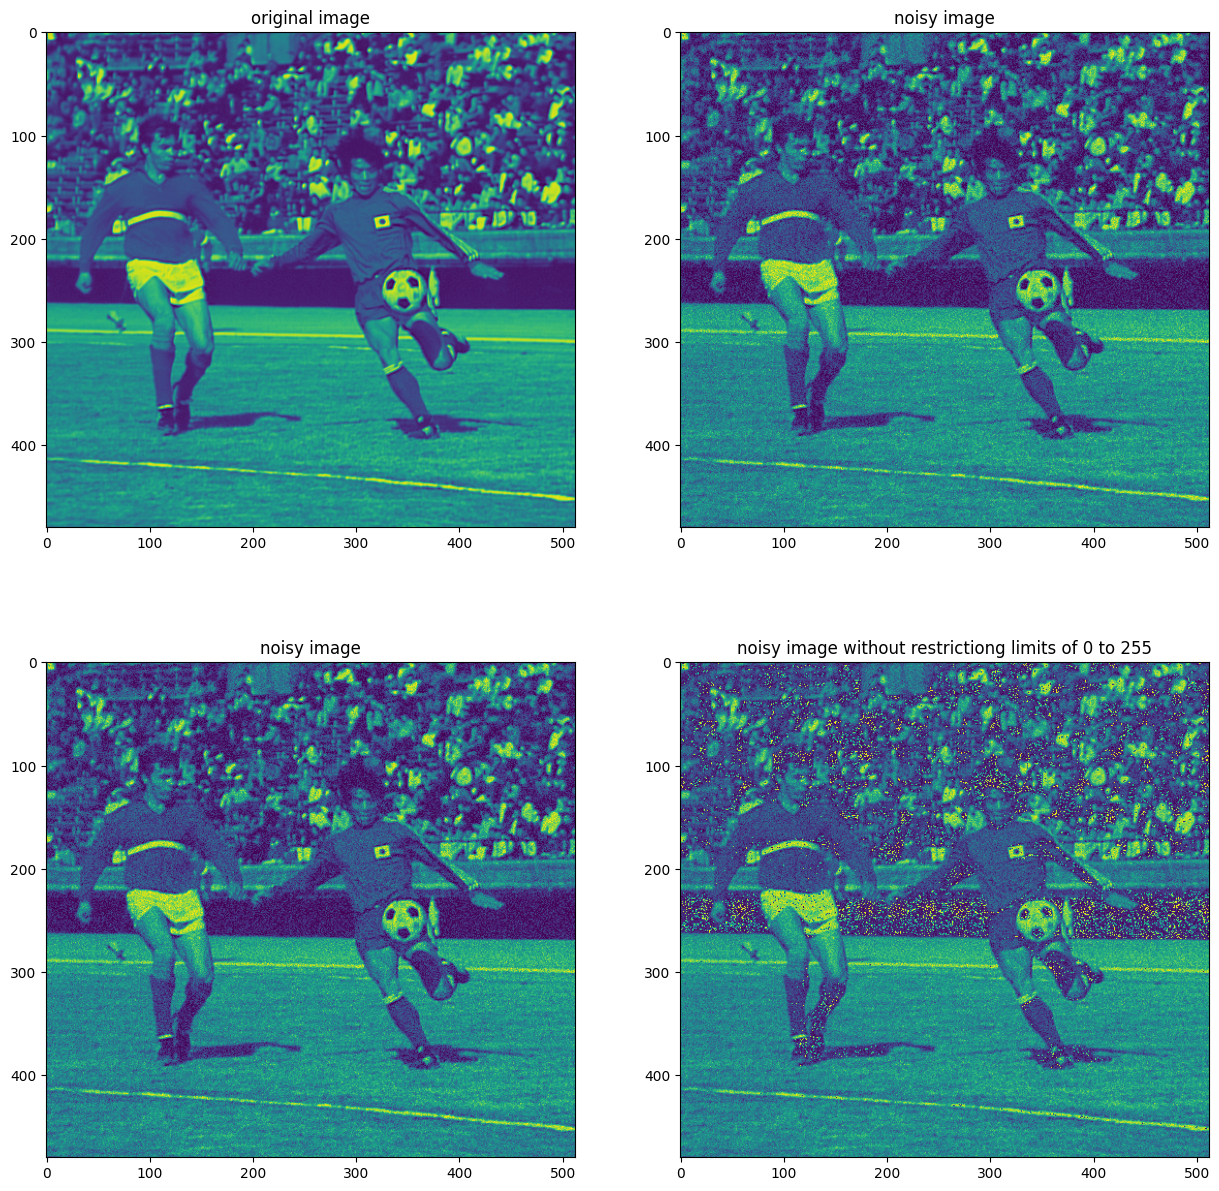

In [2]:
# generating gaussian noise
img=cv2.imread("soccer.bmp",0)
noise=np.random.normal(0,20,img.shape)
# first argument is mean, around which your distribution is present, default is 0
# second argument is spread or standard deviation, default is 1
# third is size of the array you want, if you want a 1D array with of 10 then you input 10 as argument if you want a 2D array of 3x4 then you input (3,4) as argument

noisyimg=np.clip(img+noise,0,255)

noisyimg=noisyimg.astype(np.uint8)
noisyimgnoclip=img+noise
noisyimgnoclip=noisyimgnoclip.astype(np.uint8)
plt.figure(figsize=(15,15))


plt.subplot(221)
plt.imshow(img)
plt.title("original image")

plt.subplot(222)
plt.imshow(noisyimg)
plt.title("noisy image")

plt.subplot(223)
plt.imshow(noisyimg)
plt.title("noisy image")

plt.subplot(224)
plt.imshow(noisyimgnoclip)
plt.title("noisy image without restrictiong limits of 0 to 255")

plt.show()


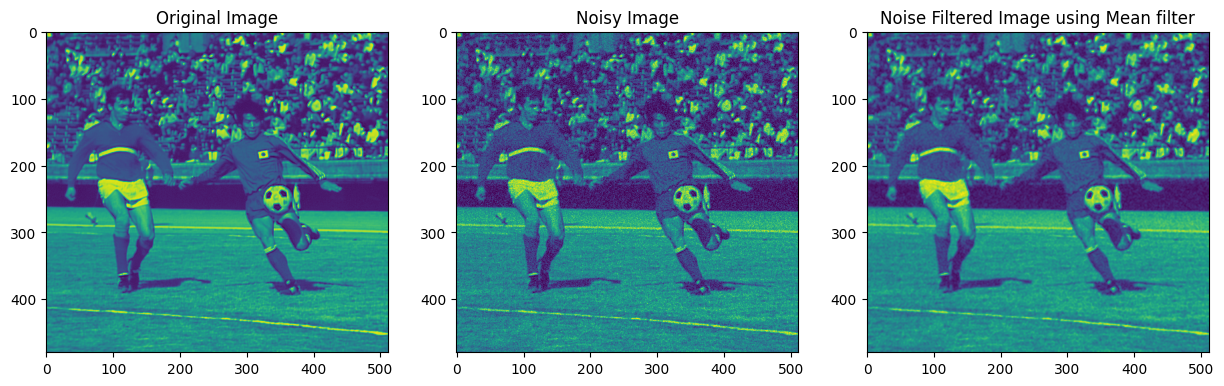

In [3]:
#Filtering using mean filter
meanfilteredImage=cv2.blur(noisyimg,(3,3))
# first argument is image that needs to be retrieved, second argument is size of window for computing mean


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(noisyimg)
plt.title("Noisy Image")

plt.subplot(1,3,3)
plt.imshow(meanfilteredImage)
plt.title("Noise Filtered Image using Mean filter")

plt.show()


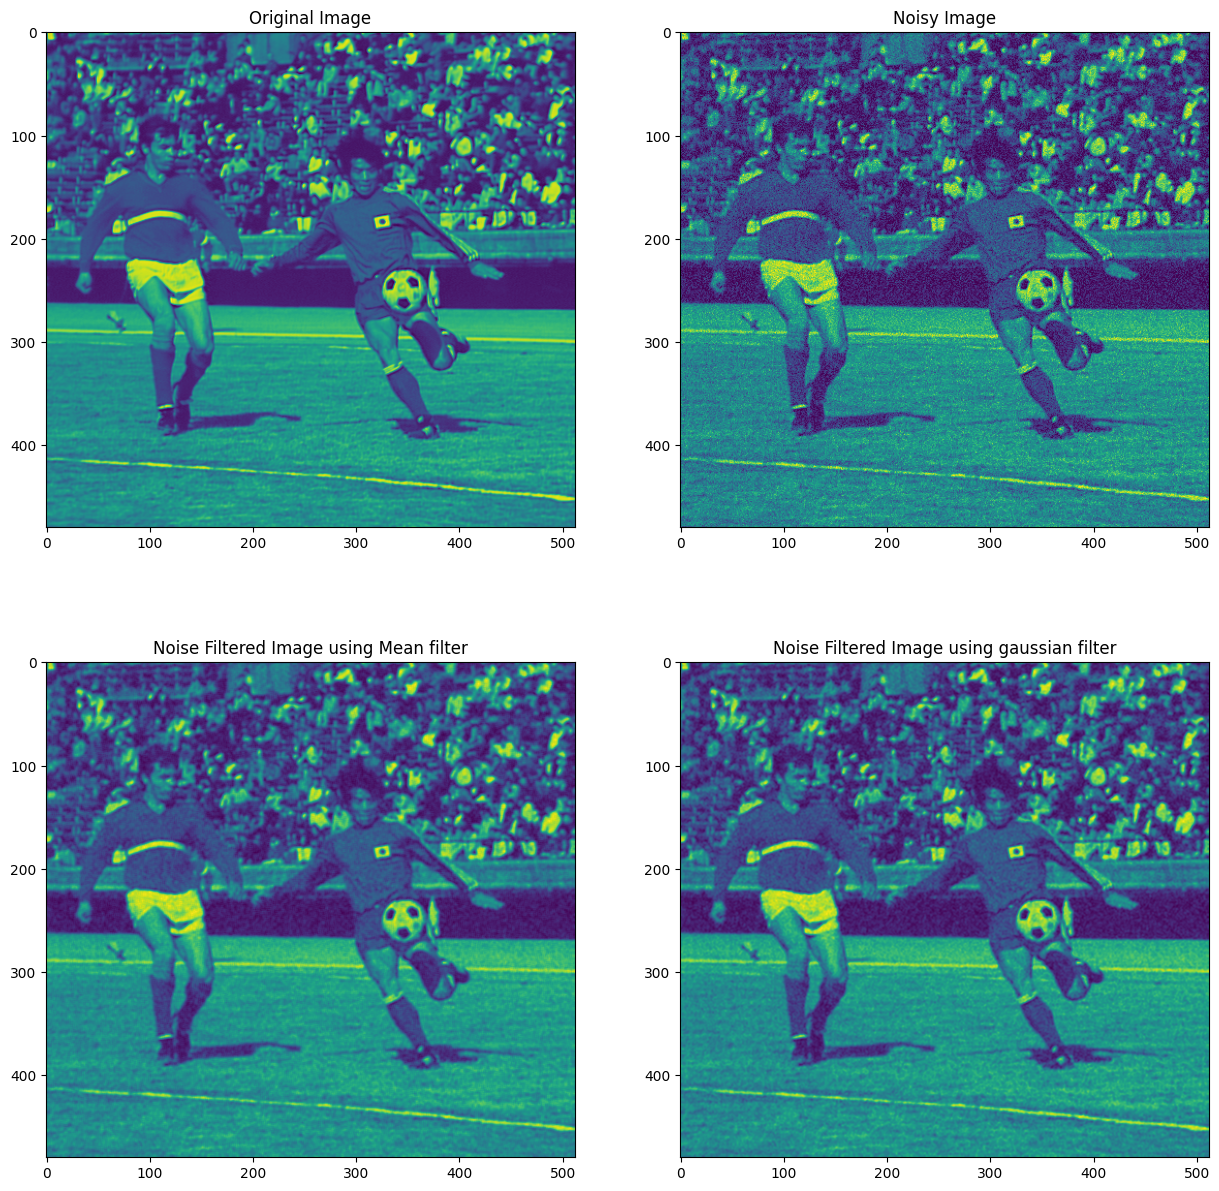

In [4]:
#Gaussian filtering
gaussianfilteredImage=cv2.GaussianBlur(noisyimg,(3,3),0)
#first argument is image that needs to be retrieved, second argument is size of window for computing gaussian weights, third argument is standard deviation


plt.figure(figsize=(15,15))
plt.subplot(2,2,1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(2,2,2)
plt.imshow(noisyimg)
plt.title("Noisy Image")

plt.subplot(2,2,3)
plt.imshow(meanfilteredImage)
plt.title("Noise Filtered Image using Mean filter")

plt.subplot(2,2,4)
plt.imshow(gaussianfilteredImage)
plt.title("Noise Filtered Image using gaussian filter")

plt.show()


Metric to compare two filter models 
Peak signal to noise ratio (PSNR)

$10log_{10}( \frac{255^2}{MSE})$

MSE-Mean squared error





In [5]:

noisyimgPSNR=cv2.PSNR(img,noisyimg)
meanFilterPSNR=cv2.PSNR(img,meanfilteredImage)
gaussianFilterPSNR=cv2.PSNR(img,gaussianfilteredImage)
print(f"PSNR for Noisy image:{noisyimgPSNR}")
print(f"PSNR for mean filter:{meanFilterPSNR}")
print(f"PSNR for gaussian filter:{gaussianFilterPSNR}")


PSNR for Noisy image:22.31845998561559
PSNR for mean filter:28.6768086432599
PSNR for gaussian filter:29.04612533850907


Problems Faced: Initially while adding gaussian noise without using np.clip to 0,255 the multiple pixels were saturating. This resulted in PSNR of the noisy image to be low.
After clipping the values between 0 to 255 the noisy image has a better PSNR and hence mean filter and gaussian filter give better results.



Adding salt and pepper noise and removing it using median filter.

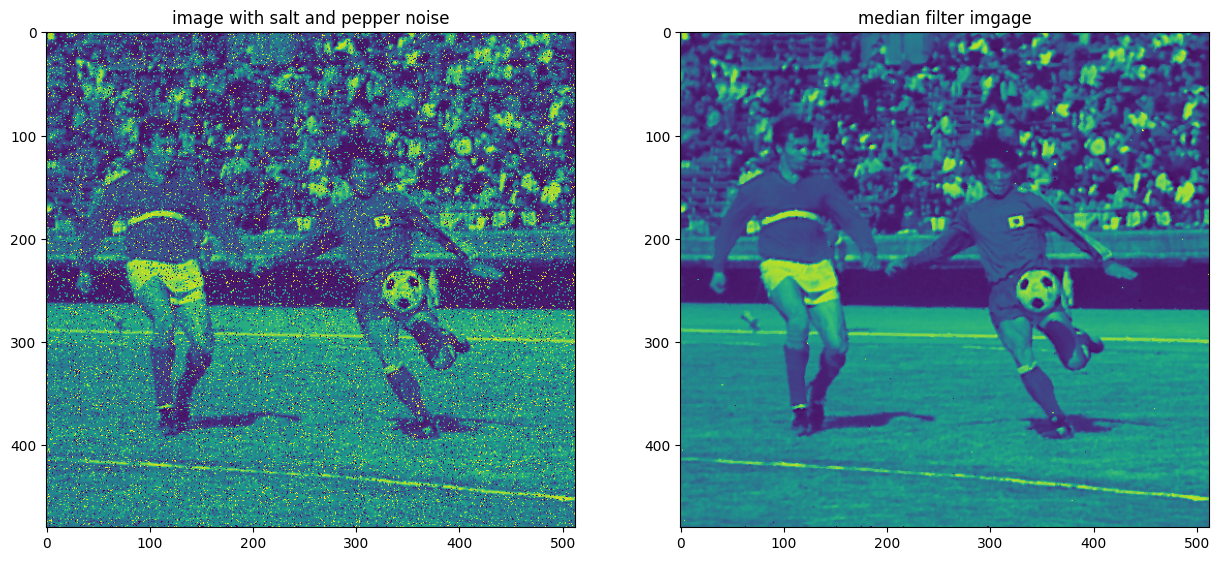

In [6]:
import random
def saltpeppernoise(original_img):
    noisy_img=original_img.copy()
    size=original_img.size
    row,col=original_img.shape
    number_of_pixels=random.randint(int(0.05*size),int(0.1*size))
    
    for i in range(0,number_of_pixels):
        #adding salt
        x_cord=random.randint(0,col-1)
        y_cord=random.randint(0,row-1)       
        noisy_img[y_cord][x_cord]=255

        #Adding pepper
        x_cord=random.randint(0,col-1)
        y_cord=random.randint(0,row-1)
        noisy_img[y_cord][x_cord]=0
    return noisy_img


spimg=saltpeppernoise(img)
medianfilter=cv2.medianBlur(spimg,3)

plt.figure(figsize=(15,15))
plt.subplot(121)
plt.imshow(spimg)
plt.title("image with salt and pepper noise")

plt.subplot(122)
plt.imshow(medianfilter)
plt.title("median filter imgage")

plt.show()


In [9]:
spimgPSNR=cv2.PSNR(img,spimg)
medianFilterPSNR=cv2.PSNR(img,meanfilteredImage)

print(f"PSNR for Noisy image:{spimgPSNR}")
print(f"PSNR for mean filter:{medianFilterPSNR}")


PSNR for Noisy image:14.092933463084803
PSNR for mean filter:28.6768086432599
